# Seq2seq으로 번역기 만들기

## 환경 설정 + Mecab 설치

In [1]:
!pip install scikit-learn tqdm konlpy python-mecab-ko

In [2]:
!pip install sentencepiece

In [3]:
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs("안녕하세요 반갑습니다"))

['안녕', '하', '세요', '반갑', '습니다']


In [4]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

from mecab import MeCab
mecab = MeCab()

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Mecab 동작 확인: {mecab.morphs('안녕하세요 반갑습니다')}")

Device: cuda
Mecab 동작 확인: ['안녕', '하', '세요', '반갑', '습니다']


In [5]:
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"현재 device: {device}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA 사용 가능: True
현재 device: cuda
GPU 이름: Tesla T4
메모리: 15.6 GB


## 데이터 로드

In [6]:
import os
# 홈 기준으로 찾기
for root, dirs, files in os.walk(os.path.expanduser("~")):
    for f in files:
        if f.endswith(".ko") or f.endswith(".en"):
            print(os.path.join(root, f))

/home/jovyan/work/AIFFEL_Quest_ENG/04_NLP/NLP01/korean-english-park.train.ko
/home/jovyan/work/AIFFEL_Quest_ENG/04_NLP/NLP01/korean-english-park.train.en


In [7]:
KO_PATH = "/home/jovyan/work/AIFFEL_Quest_ENG/04_NLP/NLP01/korean-english-park.train.ko"
EN_PATH = "/home/jovyan/work/AIFFEL_Quest_ENG/04_NLP/NLP01/korean-english-park.train.en"

with open(KO_PATH, "r", encoding="utf-8") as f:
    ko_lines = [line.strip() for line in f]
with open(EN_PATH, "r", encoding="utf-8") as f:
    en_lines = [line.strip() for line in f]

assert len(ko_lines) == len(en_lines), "두 파일의 줄 수가 달라요!"
print(f"전체 쌍 수: {len(ko_lines):,}")
print(f"샘플 [0]: KO='{ko_lines[0]}'")
print(f"          EN='{en_lines[0]}'")

전체 쌍 수: 94,123
샘플 [0]: KO='개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"'
          EN='Much of personal computing is about "can you top this?"'


## 중복 제거 (병렬쌍 유지) + cleaned_corpus 저장

In [8]:
seen = set()
cleaned_pairs = []

for ko, en in zip(ko_lines, en_lines):
    key = (ko, en)  # 쌍 단위로 중복 판단 (한쪽만 같아도 다른 쌍이면 유지)
    if key in seen:
        continue
    seen.add(key)
    cleaned_pairs.append((ko, en))

print(f"중복 제거 전: {len(ko_lines):,}")
print(f"중복 제거 후: {len(cleaned_pairs):,}")
print(f"제거된 수:    {len(ko_lines) - len(cleaned_pairs):,}")

# DataFrame으로 저장
cleaned_corpus = pd.DataFrame(cleaned_pairs, columns=["ko", "en"])
cleaned_corpus.to_csv("cleaned_corpus.csv", index=False, encoding="utf-8")
print(f"\n저장 완료: cleaned_corpus.csv")
cleaned_corpus.head()

중복 제거 전: 94,123
중복 제거 후: 78,941
제거된 수:    15,182

저장 완료: cleaned_corpus.csv


,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## 전처리 함수(한국어 정규식 추가)

In [9]:
def preprocess_kor(text):
    """한국어 전처리: 한글 + 영문 + 숫자 + 기본 구두점만 남김"""
    text = text.strip()
    # 한글(가-힣), 영문, 숫자, 기본 구두점 외 제거
    text = re.sub(r"[^가-힣A-Za-z0-9?.!,\s]", " ", text)
    # 구두점 양옆 공백
    text = re.sub(r"([?.!,])", r" \1 ", text)
    # 중복 공백 정리
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess_eng(text):
    """영어 전처리 + <start>/<end> 토큰 추가"""
    text = text.lower().strip()
    text = re.sub(r"([?.!,])", r" \1 ", text)
    text = re.sub(r"[^a-z0-9?.!,\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return f"<start> {text} <end>"


# 동작 확인
print(preprocess_kor("개인용 컴퓨터 사용의 상당 부분은 \"이것보다 뛰어날 수 있느냐?\""))
print(preprocess_eng("Much of personal computing is about \"can you top this?\""))

개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
<start> much of personal computing is about can you top this ? <end>


## 토큰화 함수 (영어 split/ 한국어 Mecab)

In [10]:
def tokenize_kor(text):
    """한국어: 전처리 → Mecab 형태소 분석"""
    text = preprocess_kor(text)
    return mecab.morphs(text)


def tokenize_eng(text):
    """영어: 전처리(<start>/<end> 추가) → split()"""
    text = preprocess_eng(text)
    return text.split()


# 동작 확인
print("KO:", tokenize_kor("개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐?"))
print("EN:", tokenize_eng("Much of personal computing is about can you top this?"))

KO: ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어날', '수', '있', '느냐', '?']
EN: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


## 전체 테이터 토큰화

In [11]:
# 빠른 실험 vs 최종 학습 토글
NUM_SAMPLES = 30000              # 빠른 실험 (~10분/epoch)
# NUM_SAMPLES = len(cleaned_corpus)   # 최종 학습 (~30분/epoch)
sample_corpus = cleaned_corpus.head(NUM_SAMPLES)
print(f"사용 데이터 수: {NUM_SAMPLES:,}")

# 토큰화 (Mecab + split)
print("\n토큰화 중...")
ko_tokens = [tokenize_kor(t) for t in tqdm(sample_corpus["ko"], desc="KO")]
en_tokens = [tokenize_eng(t) for t in tqdm(sample_corpus["en"], desc="EN")]

print(f"\nKO 첫 샘플: {ko_tokens[0]}")
print(f"EN 첫 샘플: {en_tokens[0]}")

사용 데이터 수: 30,000

토큰화 중...


EN: 100%|██████████| 30000/30000 [00:00<00:00, 34704.20it/s]


KO 첫 샘플: ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어날', '수', '있', '느냐', '?']
EN 첫 샘플: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


## 토큰 길이 ≤ 40 필터링 → kor_corpus, eng_corpus

필터링 후: 22,849쌍


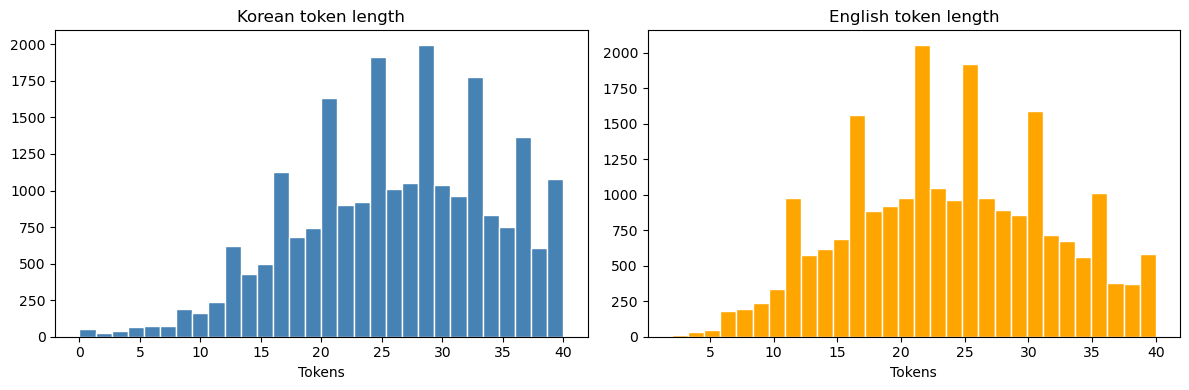

In [12]:
MAX_TOKENS = 40
kor_corpus = []
eng_corpus = []
for ko_tok, en_tok in zip(ko_tokens, en_tokens):
    if len(ko_tok) <= MAX_TOKENS and len(en_tok) <= MAX_TOKENS:
        kor_corpus.append(ko_tok)
        eng_corpus.append(en_tok)
print(f"필터링 후: {len(kor_corpus):,}쌍")

# 길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([len(t) for t in kor_corpus], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Korean token length"); axes[0].set_xlabel("Tokens")
axes[1].hist([len(t) for t in eng_corpus], bins=30, color="orange", edgecolor="white")
axes[1].set_title("English token length"); axes[1].set_xlabel("Tokens")
plt.tight_layout(); plt.show()

In [13]:
with open("kor_corpus.txt", "w", encoding="utf-8") as f:
    for tokens in kor_corpus:
        f.write(" ".join(tokens) + "\n")
with open("eng_corpus.txt", "w", encoding="utf-8") as f:
    for tokens in eng_corpus:
        f.write(" ".join(tokens) + "\n")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
VOCAB_SIZE = 8000

for lang in ["kor", "eng"]:
    spm.SentencePieceTrainer.train(
        input=f"{lang}_corpus.txt",
        model_prefix=f"{lang}_spm",
        vocab_size=VOCAB_SIZE,
        pad_id=PAD_ID, bos_id=BOS_ID, eos_id=EOS_ID, unk_id=UNK_ID,
        character_coverage=0.9995,
    )

kor_sp = spm.SentencePieceProcessor(model_file="kor_spm.model")
eng_sp = spm.SentencePieceProcessor(model_file="eng_spm.model")

print(f"한국어 vocab: {kor_sp.get_piece_size()}")
print(f"영어 vocab:   {eng_sp.get_piece_size()}")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  diffe

한국어 vocab: 8000
영어 vocab:   8000


49
trainer_interface.cc(689) LOG(INFO) Saving model: kor_spm.model
trainer_interface.cc(701) LOG(INFO) Saving vocabs: kor_spm.vocab
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: eng_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0


In [14]:
MAX_LEN = 50

class TranslationDataset(Dataset):
    def __init__(self, ko_tokens_list, en_tokens_list, max_len):
        self.ko_list = ko_tokens_list
        self.en_list = en_tokens_list
        self.max_len = max_len
    
    def __len__(self):
        return len(self.ko_list)
    
    def __getitem__(self, idx):
        ko_text = " ".join(self.ko_list[idx])
        en_text = " ".join(self.en_list[idx])
        
        src_ids = kor_sp.encode(ko_text)[:self.max_len]
        tgt_ids = eng_sp.encode(en_text)[:self.max_len - 2]
        
        tgt_input = [BOS_ID] + tgt_ids + [EOS_ID]
        
        src_ids = src_ids + [PAD_ID] * (self.max_len - len(src_ids))
        tgt_input = tgt_input + [PAD_ID] * (self.max_len - len(tgt_input))
        
        return (torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_input, dtype=torch.long))


ko_train, ko_temp, en_train, en_temp = train_test_split(
    kor_corpus, eng_corpus, test_size=0.3, random_state=SEED
)
ko_valid, ko_test, en_valid, en_test = train_test_split(
    ko_temp, en_temp, test_size=0.5, random_state=SEED
)

train_ds = TranslationDataset(ko_train, en_train, MAX_LEN)
valid_ds = TranslationDataset(ko_valid, en_valid, MAX_LEN)
test_ds  = TranslationDataset(ko_test,  en_test,  MAX_LEN)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds):,}")
print(f"Valid: {len(valid_ds):,}")
print(f"Test:  {len(test_ds):,}")

src_vocab_size = kor_sp.get_piece_size()
tgt_vocab_size = eng_sp.get_piece_size()

Train: 15,994
Valid: 3,427
Test:  3,428


## Train/Valid 분리 + Dataset / DataLoader

In [15]:
# 먼저 train 70% vs 나머지 30%
ko_train, ko_temp, en_train, en_temp = train_test_split(
    kor_corpus, eng_corpus, test_size=0.3, random_state=SEED
)

# 나머지 30%를 valid 15% vs test 15%로 다시 분할
ko_valid, ko_test, en_valid, en_test = train_test_split(
    ko_temp, en_temp, test_size=0.5, random_state=SEED
)

train_ds = TranslationDataset(ko_train, en_train, MAX_LEN)
valid_ds = TranslationDataset(ko_valid, en_valid, MAX_LEN)
test_ds  = TranslationDataset(ko_test,  en_test,  MAX_LEN)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds):,}")
print(f"Valid: {len(valid_ds):,}")
print(f"Test:  {len(test_ds):,}")

src_vocab_size = kor_sp.get_piece_size()
tgt_vocab_size = eng_sp.get_piece_size()

Train: 15,994
Valid: 3,427
Test:  3,428


## 모델 (Encoder + Attention + Decoder + Seq2Seq)

In [16]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))   # ← dropout 추가
        enc_outputs, hidden = self.gru(embedded)
        return enc_outputs, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_enc = nn.Linear(hidden_dim, hidden_dim)
        self.W_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
    def forward(self, dec_hidden, enc_outputs):
        dec_hidden = dec_hidden.unsqueeze(1)
        energy = torch.tanh(self.W_dec(dec_hidden) + self.W_enc(enc_outputs))
        scores = self.v(energy).squeeze(-1)
        return torch.softmax(scores, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(dropout)               # ← 추가
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.attention = attention
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)
    def forward(self, input_token, dec_hidden, enc_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))   # ← dropout 추가
        attn_weights = self.attention(dec_hidden.squeeze(0), enc_outputs)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs)
        gru_out, dec_hidden = self.gru(embedded, dec_hidden)
        combined = torch.cat([gru_out, context], dim=-1)
        logits = self.fc_out(combined.squeeze(1))
        return logits, dec_hidden, attn_weights


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    
    def forward(self, src, tgt_input):
        batch_size, tgt_len = tgt_input.size()
        vocab_size = self.decoder.fc_out.out_features
        enc_outputs, hidden = self.encoder(src)
        all_logits = torch.zeros(batch_size, tgt_len, vocab_size, device=self.device)
        for t in range(tgt_len):
            logits, hidden, _ = self.decoder(tgt_input[:, t], hidden, enc_outputs)
            all_logits[:, t] = logits
        return all_logits
    
    @torch.no_grad()
    def translate(self, src, max_len=40, start_id=None, end_id=None):
        self.eval()
        batch_size = src.size(0)
        enc_outputs, hidden = self.encoder(src)
        input_token = torch.full((batch_size,), start_id, dtype=torch.long, device=self.device)
        predicted_ids = []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
        for _ in range(max_len):
            logits, hidden, _ = self.decoder(input_token, hidden, enc_outputs)
            input_token = logits.argmax(dim=-1)
            predicted_ids.append(input_token)
            finished |= (input_token == end_id)
            if finished.all():
                break
        return torch.stack(predicted_ids, dim=1)

## 모델 인스턴스화
Embedding/Hidden Size 실험은 아래 두 값을 바꿔가면서 진행

In [17]:
EMB_DIM = 256       # 시도해볼 값: 128, 256, 512
HIDDEN_DIM = 512    # 시도해볼 값: 256, 512, 1024

src_vocab_size = kor_sp.get_piece_size()  
tgt_vocab_size = eng_sp.get_piece_size()  

encoder = Encoder(src_vocab_size, EMB_DIM, HIDDEN_DIM, dropout=0.5).to(device)
attention = BahdanauAttention(HIDDEN_DIM).to(device)
decoder = Decoder(tgt_vocab_size, EMB_DIM, HIDDEN_DIM, attention, dropout=0.5).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 파라미터 수: {n_params:,}")

학습 파라미터 수: 15,187,264


## 학습함수

In [20]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Train", leave=False)
    for src, tgt in pbar:
        src = src.to(device); tgt = tgt.to(device)
        # tgt = [<start>, w1, w2, ..., <end>] → 한 칸 어긋난 입력/라벨
        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]
        
        optimizer.zero_grad()
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    for src, tgt in loader:
        src = src.to(device); tgt = tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

## 학습 실행

In [21]:
# Early Stopping
EPOCHS = 30        # 상한선 (Early Stopping이 보통 더 일찍 멈춤)
PATIENCE = 3       # valid loss 3회 연속 개선 안 되면 중단
LR = 1e-3

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {"train_loss": [], "valid_loss": []}
best_valid_loss = float("inf")
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    valid_loss = evaluate(model, valid_loader, criterion)
    scheduler.step(valid_loss)   # ← 추가
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:2d}/{EPOCHS}  train={train_loss:.4f}  valid={valid_loss:.4f}  lr={current_lr:.2e}")
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ✓ best 저장")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping. Best={best_valid_loss:.4f}")
            break

# 학습 종료 후 best 시점 모델로 복원
model.load_state_dict(torch.load("best_model.pt"))
print("✓ best 모델로 복원 완료. 이제 translate() 사용 가능.")

Epoch  1/30  train=4.7236  valid=4.1978  lr=1.00e-03
  ✓ best 저장


Epoch  2/30  train=4.1030  valid=3.9729  lr=1.00e-03
  ✓ best 저장


Epoch  3/30  train=3.8647  valid=3.8397  lr=1.00e-03
  ✓ best 저장


Epoch  4/30  train=3.7146  valid=3.7531  lr=1.00e-03
  ✓ best 저장


Epoch  5/30  train=3.6060  valid=3.6989  lr=1.00e-03
  ✓ best 저장


...

Epoch 22/30  train=2.7436  valid=3.3664  lr=1.00e-03


Epoch 23/30  train=2.7127  valid=3.3594  lr=1.00e-03
  ✓ best 저장


Epoch 24/30  train=2.6842  valid=3.3606  lr=1.00e-03


Epoch 25/30  train=2.6579  valid=3.3668  lr=1.00e-03


Epoch 26/30  train=2.6315  valid=3.3643  lr=5.00e-04

Early stopping. Best=3.3594
✓ best 모델로 복원 완료. 이제 translate() 사용 가능.


## 학습 곡선 + 번역 테스트

In [23]:
def translate_korean(sentence, model, max_len=50):
    # 전처리 + Mecab 분리 + SentencePiece 인코딩
    ko_tokens = tokenize_kor(sentence)
    ko_text = " ".join(ko_tokens)
    src_ids = kor_sp.encode(ko_text)[:MAX_LEN]
    src_ids = src_ids + [PAD_ID] * (MAX_LEN - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    # 번역
    pred_ids = model.translate(src, max_len=max_len, start_id=BOS_ID, end_id=EOS_ID)
    pred_ids = pred_ids[0].tolist()
    
    # EOS 이전까지만
    if EOS_ID in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(EOS_ID)]
    
    # SentencePiece가 알아서 단어 결합 + 공백 복원
    translation = eng_sp.decode(pred_ids)
    return translation


# 테스트
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]
for s in test_sentences:
    translation = translate_korean(s, model)
    print(f"입력: {s}")
    print(f"번역: {translation}\n")

입력: 오바마는 대통령이다.
번역: <start> obama is the first time in the war . <end>

입력: 시민들은 도시 속에 산다.
번역: <start> they were joined . <end>

입력: 커피는 필요 없다.
번역: <start> we can t do anything . <end>

입력: 일곱 명의 사망자가 발생했다.
번역: <start> the attacks were killed . <end>



In [ ]:
# 학습 끝나고 best 모델 로드된 상태에서 test 평가 (단 1회)
test_loss = evaluate(model, test_loader, criterion)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"   (참고) Best Valid Loss: {best_valid_loss:.4f}")

###  plot_attention 코드 (시각화 전용)

Input:       오바마는 대통령이다.
Translation: <start> obama is the first time in the war . <end>



/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_456/3386152148.py:75: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

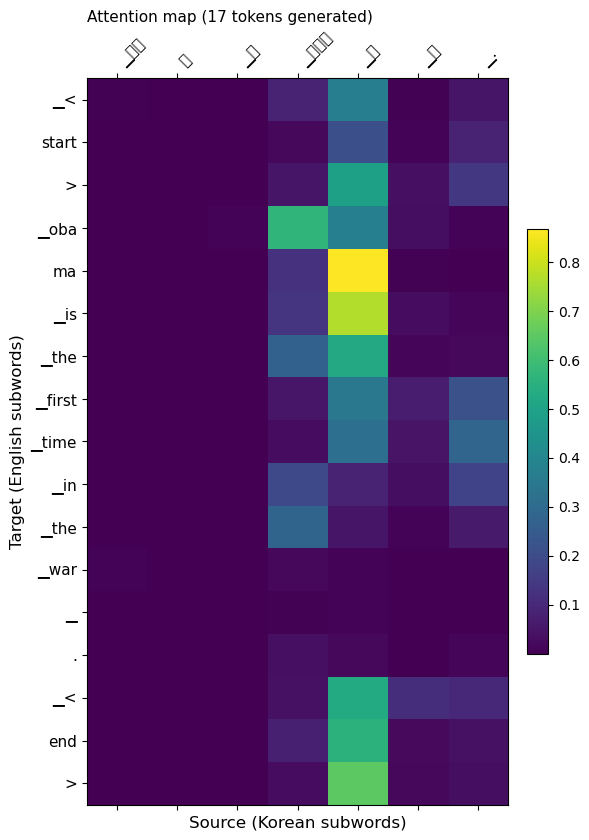

In [25]:
@torch.no_grad()
def translate_with_attention(sentence, model, max_len=50):
    """Translation + attention weights"""
    model.eval()
    
    # Mecab + SentencePiece
    ko_tokens = tokenize_kor(sentence)
    ko_text = " ".join(ko_tokens)
    src_ids = kor_sp.encode(ko_text)[:MAX_LEN]
    src_pieces = kor_sp.encode(ko_text, out_type=str)[:MAX_LEN]  # 시각화 라벨용
    src_ids = src_ids + [PAD_ID] * (MAX_LEN - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    # Encoder
    enc_outputs, hidden = model.encoder(src)
    input_token = torch.full((1,), BOS_ID, dtype=torch.long, device=device)
    
    # Decoder step by step
    predicted_ids = []
    all_attentions = []
    
    for _ in range(max_len):
        logits, hidden, attn = model.decoder(input_token, hidden, enc_outputs)
        input_token = logits.argmax(dim=-1)
        predicted_ids.append(input_token.item())
        all_attentions.append(attn[0].cpu().numpy())
        if input_token.item() == EOS_ID:
            break
    
    # Truncate at EOS
    if EOS_ID in predicted_ids:
        end_idx = predicted_ids.index(EOS_ID)
        predicted_ids = predicted_ids[:end_idx]
        all_attentions = all_attentions[:end_idx]
    
    # SentencePiece pieces (시각화 라벨용)
    pred_pieces = [eng_sp.id_to_piece(i) for i in predicted_ids]
    # 최종 번역 (공백 자동 결합)
    translation = eng_sp.decode(predicted_ids)
    
    return {
        "src_pieces": src_pieces,
        "pred_pieces": pred_pieces,
        "translation": translation,
        "attentions": np.array(all_attentions),
    }


def plot_attention(sentence, model, max_len=50):
    """Translate and plot attention heatmap"""
    result = translate_with_attention(sentence, model, max_len)
    
    src_pieces = result["src_pieces"]
    pred_pieces = result["pred_pieces"]
    attn = result["attentions"][:, :len(src_pieces)]
    
    print(f"Input:       {sentence}")
    print(f"Translation: {result['translation']}\n")
    
    fig, ax = plt.subplots(figsize=(max(6, len(src_pieces) * 0.7),
                                     max(4, len(pred_pieces) * 0.5)))
    im = ax.matshow(attn, cmap="viridis", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_xticks(range(len(src_pieces)))
    ax.set_xticklabels(src_pieces, rotation=45, ha="left", fontsize=11)
    ax.set_yticks(range(len(pred_pieces)))
    ax.set_yticklabels(pred_pieces, fontsize=11)
    
    ax.set_xlabel("Source (Korean subwords)", fontsize=12)
    ax.set_ylabel("Target (English subwords)", fontsize=12)
    ax.set_title(f"Attention map ({len(pred_pieces)} tokens generated)", 
                 fontsize=11, loc="left")
    
    plt.tight_layout()
    plt.show()


# 시각화 예시 한 문장
plot_attention("오바마는 대통령이다.", model)

Early Stopping  
EMB 256, HIDDEN 512  
dropout 0.5  
NUM_SAMPLES = len(cleaned_corpus)  
L2정칙화 - optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)  
LR = 1e-3  
weight_decay = 1e-4  
**현재 이 조합이 가장 좋은 결과**

하이퍼 파라미터를 조금씩 변경하면서 학습 성능을 높이는데까지는 내가 할수있는 최적의 조합을 찾아냈는데 학습을 최적화했다해서 번역의 퀄리티가 좋았던건 아니여서 다시 코드 자체에서 변경이 필요했다.  
코드 구성을 생각하면서 배웠던 부분을 적절하게 잘 활용을 했어야했는데 아직까지도 코드 보는덴 많은 도움이 필요하다보니 수정하면서 뺴먹은 부분이 많다는걸 인지할 수 있었다.  
하이퍼파라미터도 조금씩 변경하면서 여러번 반복해 시간이 상당히 많이 걸려 더 테스트 못한 아쉬움도 있다.  
Epoch이나 batch_size를 조금 포기하더라도 더 테스트를 해봤어야하는 생각도 들지만 그동안 배웠던 부분에 대해 적절하게 하이퍼파라미터를 조절하면서 다양한 결과값을 비교하면서 다양한 성능테스트 하면서 많이 배웠다고 생각한다.  
마지막 최종 수정 과정에서 Bidirectional Encoder 놓쳤다는걸 알았다. 과제떄마다 기초를 잘해야지 하는데 여전히 시작엔 갈피를 제대로 잡지 못해 마지막엔 늘 성찰시간이 긴거 같은데, 못찾은 놓친 부분이 있는지 더 알아보는것과 배운 부분을 잘 활용하기 위해 정리가 더 필요할거같단 생각이 든다. 

여러 디버깅 과정이 있었지만 코드를 계속 추가하고 변경하면서 처음에는 단어 단위 토크나이저(kor_tokenizer)로 시작해다가 나중에 SentencePiece(kor_sp)로 전환했는데, 가장 최근에 배운 부분을 놓쳐서 코드 작성에 부족함이 많다는걸 배우는 시간이였다.   
최종 결과값이 아직도 만족스럽지 못해서 수정 과정이 더 필요한데 레이블을 주고 학습을 했으면 결과값이 더 좋았을거같다.  

__모델/데이터의 본질적 한계 인식__  

GRU+Attention은 2014년 수준 아키텍처로 한-영처럼 어순이 다른 언어쌍에서는 한계가 명확  
94k 데이터는 NMT 기준 매우 적은 양 (상용 모델은 100만+ 사용)  
결과적으로 어떤 하이퍼파라미터 튜닝도 일정 수준 이상의 품질은 만들 수 없었음  
이를 통해 "모델 선택 자체가 가장 큰 결정"임을 체감  